

Model topics found on Twitter using matrix factorization. Assumes every tweet is a combination of several topics weighted by their prevailance in the text. 

The dataset is obtained from [Kaggle](https://www.kaggle.com/smid80/coronavirus-covid19-tweets-late-april?select=2020-04-30+Coronavirus+Tweets.CSV) and the preprocessing is [here](https://www.kaggle.com/satanizer/covid-19-tweets-analysis). 

---

# Setup

## Data Loading



In [128]:
import numpy as np
import pandas as pd

In [129]:

text = pd.read_csv('tweets-2020-4-30.csv')
np.random.seed(416)

In [131]:
text = text.fillna('')
text.tail()

,text
119142,check results sociallydistant airshow weeks sh...
119143,covid sunsets ra sunset rona ronasunsets duskt...
119144,one favorite performances star band lit livemu...
119145,reminder massmedical members weekly member cal...
119146,i’d never thought primark’s origin hq owns sur...



```python
# tweets in English
text = data['text'][data['lang']=='en']

# remove URL 
text = text.apply(lambda x: re.sub(r"https\S+", "", str(x)))

# make lower 
text = text.str.lower()

# remove punctuation
text = text.apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))

# remove stopwords and COVID trms
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
stop_words.update(['#coronavirus', '#coronavirusoutbreak', 
                   '#coronavirusPandemic', '#covid19', '#covid_19', 
                   '#epitwitter', '#ihavecorona', 'amp', 'coronavirus', 
                   'covid19','covid-19', 'covidー19'])

def remove_stopwords(tweet):
    words = tweet.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)  # Trick to make string separated by spaces

text = text.apply(remove_stopwords)
```

In [132]:
from sklearn.feature_extraction.text import TfidfVectorizer

# create matrix
vectorizer = TfidfVectorizer(max_df=0.95) 
tf_idf = vectorizer.fit_transform(text['text'])
feature_names = vectorizer.get_feature_names_out()

tf_idf.shape

(119147, 183012)

### 🔍 **Question 1** Counts

Make two variables `num_tweets` and `num_words` that store the number of tweets in our dataset and number of words in our analysis respectively. Use the number of words as the number of features after doing the TF-IDF computation.

In [134]:
num_tweets = tf_idf.shape[0]
num_words = tf_idf.shape[1]


Set up an NMF model with 5 components and fit it to our TF-IDF data.

In [136]:

from sklearn.decomposition import NMF

nmf = NMF(n_components=5, init='nndsvd')
tweets_projected = nmf.fit_transform(tf_idf)

In [138]:
nmf.components_.shape

(5, 183012)

In [139]:
tweets_projected.shape

(119147, 5)

# Analyzing Topics

We are now interested in inspecting each topic to find the most prevelant or meaningful words for that topic. We'll consider the words with the highest weights for a topic in NMF model to be the most important words for that topic. Recall that the words themselves are stored in a variable called `feature_names`.

In [141]:

small_words = ['dogs', 'cats', 'axolotl']
small_weights = np.array([1, 4, 2])

indices = np.flip(np.argsort(small_weights))
sorted_small_words = list((np.array(small_words))[indices])
sorted_small_words

[np.str_('cats'), np.str_('axolotl'), np.str_('dogs')]

In [142]:

def words_from_topic(topic, feature_names):
  """
  Sorts the words by their weight in the given topic from largest to smallest.
  topic and feature_names should have the same number of entries.

  Args:
  - topic (np.array): A numpy array with one entry per word that shows the weight in this topic.
  - feature_names (list): A list of words that each entry in topic corresponds to

  Returns:
  - A list of words in feature_names sorted by weight in topic from largest to smallest. 
  """

  # TODO implement this function
  indices = np.flip(np.argsort(topic))
  x = list((np.array(feature_names))[indices])
  return x 



In [143]:
def print_top_words(components, feature_names, n_top_words):
    """ 
    print_top_words prints the first n_top_words for each topic in components
    """
    for topic_index, topic in enumerate(components):
        ordered_words = words_from_topic(topic, feature_names)
        top_words = ', '.join(ordered_words[:n_top_words])
        print(f'Topic: #{topic_index}: {top_words}')

print_top_words(nmf.components_, feature_names, 10)

Topic: #0: people, lockdown, get, home, stay, like, one, time, know, go
Topic: #1: cases, new, deaths, total, confirmed, reported, number, positive, reports, today
Topic: #2: spread, app, help, selfreporting, symptoms, download, sooner, identify, slow, daily
Topic: #3: us, china, join, trump, let, million, drug, manmade, intelligence, says
Topic: #4: pandemic, health, support, help, crisis, workers, global, news, need, read


Look at a specific tweet (index 40151)

In [144]:
index = 40151
print(text.iloc[index]['text'])
print(tweets_projected[index])

attention seattle shoppers grocery stores working hard keep employees customers safe part help slow spread ☑️ limit trips ☑️ respect special shopping hours ☑️ follow socialdistance guidance stores wegotthisseattle
[0.00823661 0.         0.02895533 0.         0.01529455]


In [146]:
### edTest(test_q7_largest_topic) ###

# TODO find index of largest topic
from scipy import stats

largest_topic = stats.mode(tweets_projected.argmax(axis=1))[0]
largest_topic

np.int64(4)

# Smaller dimension

In [147]:
nmf_small = NMF(n_components=3, init='nndsvd')
tweets_projected_small = nmf_small.fit_transform(tf_idf)

In [148]:
print_top_words(nmf_small.components_, feature_names, 10)

Topic: #0: us, people, pandemic, lockdown, need, get, health, time, home, like
Topic: #1: cases, new, deaths, total, confirmed, reported, number, positive, reports, today
Topic: #2: help, spread, app, selfreporting, symptoms, download, sooner, identify, slow, feel


Now that we have 3 values for each tweet, we can actually plot each tweet in 3D space to see how all the tweets relate to each other. The following cell does exactly that. You don't need to understand all the specifics of how to make a 3D plot, but just note it is using the 3 topic values for each tweet as the x, y, z coordinates

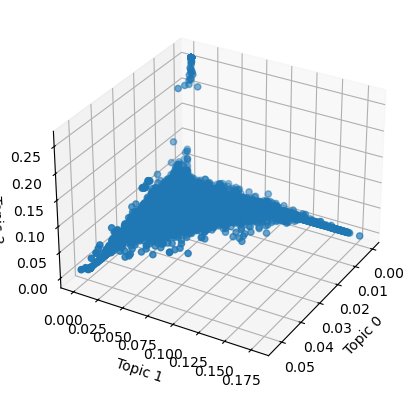

In [149]:
import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(tweets_projected_small[:, 0], tweets_projected_small[:, 1], tweets_projected_small[:, 2])

ax.set_xlabel('Topic 0')
ax.set_ylabel('Topic 1')
ax.set_zlabel('Topic 2')

ax.view_init(30, 30)


### Outlier Tweets

In [153]:

arr = []
for i in range(tweets_projected_small.shape[0]):
    if (tweets_projected_small[i, 2] >= .15):
        arr.append(i)
outlier_tweets = text.iloc[arr]['text'].unique()

In [154]:
outlier_tweets

array(['alabama reports 18 new cases 5 new deaths bringing total confirmed cases 6943 267 total deaths 39 new cases 12 new deaths reported today coronavirusoutbreak',
       'veteran affairs reports 15 new cases bringing total confirmed cases 8611 494 total deaths 337 new cases 10 new deaths reported today coronavirusoutbreak',
       'germany reports 420 new cases 44 new deaths bringing total confirmed cases 162950 6616 total deaths 1411 new cases 149 new deaths reported today coronavirusoutbreak',
       'usa reports 82 new cases 10 new deaths bringing total confirmed cases 1064819 61680 total deaths 625 new cases 24 new deaths reported today coronavirusoutbreak',
       'india reports 1170 new cases 72 new deaths bringing total confirmed cases 34780 1151 total deaths 1718 new cases reported today coronavirusoutbreak',
       'georgia reports 30 new cases bringing total confirmed cases 26155 1120 total deaths 504 new cases 22 new deaths reported today coronavirusoutbreak',
       'ge